# Leakage-Safe Scikit-learn Baseline Modeling and Evaluation

This notebook remediates duplicate-text leakage in the internal 2024 modeling workflow before Week 8 routing analysis.

It performs four controlled stages:

1. Audit normalized duplicate-text groups using aggregate counts only.
2. Exclude conflicting-label text groups and retain one row from repeated same-label groups.
3. Reserve one deterministic `StratifiedGroupKFold` fold as an untouched final internal test set.
4. Select among Logistic Regression, Multinomial Naive Bayes, and Linear SVM using group-aware cross-validation on development data only, then evaluate the selected pipeline once on the final test set.

Guardrails: use only the local 2024 processed dataset, do not load the 2025 holdout, do not display complaint narratives, and do not claim production readiness.

## 1. Imports, Paths, and Locked Version 1 Scope

In [1]:
from pathlib import Path
import hashlib
import platform
import textwrap

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedGroupKFold, cross_validate, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC


def find_project_root(start_path: Path) -> Path:
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        expected = candidate / "data" / "processed" / "cfpb_complaints_2024_cleaned.csv"
        if expected.exists() and (candidate / ".gitignore").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root and local 2024 processed dataset.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cfpb_complaints_2024_cleaned.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "models"
CONFUSION_MATRIX_PATH = FIGURES_DIR / "confusion_matrix.png"
MODEL_PATH = MODEL_DIR / "best_tfidf_classifier.joblib"

LOCKED_CATEGORIES = (
    "Credit reporting or other personal consumer reports",
    "Debt collection",
    "Credit card",
    "Checking or savings account",
    "Mortgage",
    "Money transfer, virtual currency, or money service",
    "Student loan",
    "Vehicle loan or lease",
)
MIN_CATEGORY_ROWS_FOR_LOCKED_SCOPE = 500
OUTER_SPLITS = 5
DEVELOPMENT_CV_SPLITS = 5
FINAL_TEST_FOLD = 0
RANDOM_STATE = 42

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Input dataset: {DATA_PATH.relative_to(PROJECT_ROOT)}")
print(f"Locked Version 1 categories: {len(LOCKED_CATEGORIES)}")
print("2025 holdout status: not loaded or used.")

Project root: <project-root>
Input dataset: data\processed\cfpb_complaints_2024_cleaned.csv
Locked Version 1 categories: 8
2025 holdout status: not loaded or used.


## 2. Preflight and Aggregate Duplicate-Leakage Audit

In [2]:
df = pd.read_csv(DATA_PATH)

required_columns = {"clean_complaint_text", "product"}
missing_columns = sorted(required_columns.difference(df.columns))
if missing_columns:
    raise ValueError(f"Missing required modeling columns: {missing_columns}")

if df["clean_complaint_text"].isna().any() or df["product"].isna().any():
    raise ValueError("The processed modeling columns must not contain missing values.")


def normalize_cleaned_text(value: object) -> str:
    '''Normalize surrounding and repeated whitespace without exposing text.'''
    return " ".join(str(value).strip().split())


def stable_text_hash(value: object) -> str:
    normalized = normalize_cleaned_text(value)
    return hashlib.sha256(normalized.encode("utf-8")).hexdigest()


audit_df = df[["clean_complaint_text", "product"]].copy()
audit_df["normalized_text_hash"] = audit_df["clean_complaint_text"].map(stable_text_hash)

group_sizes = audit_df.groupby("normalized_text_hash", sort=False).size()
group_label_counts = audit_df.groupby("normalized_text_hash", sort=False)["product"].nunique()
conflicting_hashes = set(group_label_counts[group_label_counts > 1].index)

total_2024_rows = len(audit_df)
exact_duplicate_rows = int(df.duplicated().sum())
normalized_pair_duplicate_rows = int(
    audit_df.duplicated(["normalized_text_hash", "product"]).sum()
)
unique_normalized_texts = int(audit_df["normalized_text_hash"].nunique())
multirow_normalized_text_groups = int((group_sizes > 1).sum())
conflicting_label_groups = len(conflicting_hashes)
rows_in_conflicting_groups = int(
    audit_df["normalized_text_hash"].isin(conflicting_hashes).sum()
)

print("Aggregate duplicate audit (no complaint narratives shown):")
print(f"- Total 2024 rows: {total_2024_rows:,}")
print(f"- Exact duplicate rows: {exact_duplicate_rows:,}")
print(f"- Normalized text-and-label duplicate rows: {normalized_pair_duplicate_rows:,}")
print(f"- Unique normalized complaint texts: {unique_normalized_texts:,}")
print(f"- Multirow normalized-text groups: {multirow_normalized_text_groups:,}")
print(f"- Conflicting-label normalized-text groups: {conflicting_label_groups:,}")
print(f"- Rows in conflicting-label groups: {rows_in_conflicting_groups:,}")

original_scope_df = audit_df[audit_df["product"].isin(LOCKED_CATEGORIES)].copy()

# Reproduce the superseded row-level split for aggregate leakage measurement only.
original_train_df, original_test_df = train_test_split(
    original_scope_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=original_scope_df["product"],
)
original_train_hashes = set(original_train_df["normalized_text_hash"])
original_overlap_mask = original_test_df["normalized_text_hash"].isin(original_train_hashes)
original_overlap_rows = int(original_overlap_mask.sum())
original_overlap_percent = float(original_overlap_mask.mean() * 100)

print("Superseded row-level split leakage:")
print(f"- Modeling rows: {len(original_scope_df):,}")
print(f"- Training rows: {len(original_train_df):,}")
print(f"- Test rows: {len(original_test_df):,}")
print(f"- Test rows whose normalized text appears in training: {original_overlap_rows:,}")
print(f"- Test overlap percentage: {original_overlap_percent:.2f}%")

Aggregate duplicate audit (no complaint narratives shown):
- Total 2024 rows: 50,000
- Exact duplicate rows: 16,006
- Normalized text-and-label duplicate rows: 16,006
- Unique normalized complaint texts: 33,918
- Multirow normalized-text groups: 4,158
- Conflicting-label normalized-text groups: 74
- Rows in conflicting-label groups: 1,781
Superseded row-level split leakage:
- Modeling rows: 49,196
- Training rows: 39,356
- Test rows: 9,840
- Test rows whose normalized text appears in training: 3,876
- Test overlap percentage: 39.39%


## 3. Conservative Version 1 Duplicate Policy

In [3]:
scope_conflict_mask = original_scope_df["normalized_text_hash"].isin(conflicting_hashes)
scope_rows_excluded_for_conflicts = int(scope_conflict_mask.sum())
scope_without_conflicts = original_scope_df.loc[~scope_conflict_mask].copy()

remediated_df = scope_without_conflicts.drop_duplicates(
    subset=["normalized_text_hash", "product"],
    keep="first",
).reset_index(drop=True)

same_label_duplicate_rows_removed = len(scope_without_conflicts) - len(remediated_df)
rows_after_remediation = len(remediated_df)

remaining_label_counts = remediated_df.groupby("normalized_text_hash")["product"].nunique()
remaining_category_counts = remediated_df["product"].value_counts().reindex(LOCKED_CATEGORIES)

assert int(remaining_label_counts.max()) == 1, "Conflicting-label text groups remain."
assert remediated_df["normalized_text_hash"].is_unique, "Repeated text groups remain."
assert set(remediated_df["product"].unique()) == set(LOCKED_CATEGORIES)

too_small = remaining_category_counts[remaining_category_counts < MIN_CATEGORY_ROWS_FOR_LOCKED_SCOPE]
if not too_small.empty:
    raise ValueError(
        f"Locked categories fell below the {MIN_CATEGORY_ROWS_FOR_LOCKED_SCOPE}-row minimum "
        "for the locked scope after remediation: "
        + ", ".join(f"{label}={count}" for label, count in too_small.items())
    )

remediation_category_table = pd.DataFrame(
    {
        "before": original_scope_df["product"].value_counts().reindex(LOCKED_CATEGORIES),
        "after": remaining_category_counts,
    }
)
remediation_category_table["removed"] = (
    remediation_category_table["before"] - remediation_category_table["after"]
)

print("Duplicate policy results:")
print(f"- Locked-scope rows before remediation: {len(original_scope_df):,}")
print(f"- Conflicting-label groups excluded: {conflicting_label_groups:,}")
print(f"- Locked-scope rows excluded with conflicting groups: {scope_rows_excluded_for_conflicts:,}")
print(f"- Repeated same-label rows removed: {same_label_duplicate_rows_removed:,}")
print(f"- Rows after remediation: {rows_after_remediation:,}")
print(f"- Unique text groups after remediation: {remediated_df['normalized_text_hash'].nunique():,}")
print("Category counts before and after remediation:")
print(remediation_category_table.to_string())

Duplicate policy results:
- Locked-scope rows before remediation: 49,196
- Conflicting-label groups excluded: 74
- Locked-scope rows excluded with conflicting groups: 1,780
- Repeated same-label rows removed: 14,374
- Rows after remediation: 33,042


- Unique text groups after remediation: 33,042
Category counts before and after remediation:
                                                     before  after  removed
product                                                                    
Credit reporting or other personal consumer reports   36128  21639    14489
Debt collection                                        5357   3911     1446
Credit card                                            2735   2535      200
Checking or savings account                            2146   2141        5
Mortgage                                                887    885        2
Money transfer, virtual currency, or money service      725    724        1
Student loan                                            628    628        0
Vehicle loan or lease                                   590    579       11


## 4. Leakage-Safe Development and Final Internal Test Split

In [4]:
outer_splitter = StratifiedGroupKFold(
    n_splits=OUTER_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
outer_fold_indices = list(
    outer_splitter.split(
        remediated_df["clean_complaint_text"],
        remediated_df["product"],
        groups=remediated_df["normalized_text_hash"],
    )
)

development_indices, final_test_indices = outer_fold_indices[FINAL_TEST_FOLD]
development_df = remediated_df.iloc[development_indices].reset_index(drop=True)
final_test_df = remediated_df.iloc[final_test_indices].reset_index(drop=True)

development_groups = set(development_df["normalized_text_hash"])
final_test_groups = set(final_test_df["normalized_text_hash"])
development_test_overlap = development_groups.intersection(final_test_groups)

assert len(development_test_overlap) == 0, "Normalized-text groups cross development/test splits."
assert set(development_df["product"].unique()) == set(LOCKED_CATEGORIES)
assert set(final_test_df["product"].unique()) == set(LOCKED_CATEGORIES)

split_category_table = pd.DataFrame(
    {
        "development": development_df["product"].value_counts().reindex(LOCKED_CATEGORIES),
        "final_test": final_test_df["product"].value_counts().reindex(LOCKED_CATEGORIES),
    }
)

print("Leakage-safe split summary:")
print(f"- Outer splitter: StratifiedGroupKFold(n_splits={OUTER_SPLITS}, shuffle=True, random_state={RANDOM_STATE})")
print(f"- Deterministic final test fold: {FINAL_TEST_FOLD}")
print(f"- Development rows: {len(development_df):,}")
print(f"- Final internal test rows: {len(final_test_df):,}")
print(f"- Development unique groups: {len(development_groups):,}")
print(f"- Final test unique groups: {len(final_test_groups):,}")
print(f"- Development/test normalized-text overlap: {len(development_test_overlap):,}")
print("Class distribution by split:")
print(split_category_table.to_string())

Leakage-safe split summary:
- Outer splitter: StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
- Deterministic final test fold: 0
- Development rows: 26,433
- Final internal test rows: 6,609
- Development unique groups: 26,433
- Final test unique groups: 6,609
- Development/test normalized-text overlap: 0
Class distribution by split:
                                                     development  final_test
product                                                                     
Credit reporting or other personal consumer reports        17311        4328
Debt collection                                             3128         783
Credit card                                                 2028         507
Checking or savings account                                 1713         428
Mortgage                                                     708         177
Money transfer, virtual currency, or money service           580         144
Student loan                     

## 5. Development-Only Group-Aware Model Comparison

In [5]:
model_pipelines = {
    "TF-IDF + Logistic Regression": Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "TF-IDF + Multinomial Naive Bayes": Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2),
            ),
            ("classifier", MultinomialNB()),
        ]
    ),
    "TF-IDF + Linear SVM": Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2),
            ),
            (
                "classifier",
                LinearSVC(
                    random_state=RANDOM_STATE,
                    class_weight="balanced",
                    max_iter=10000,
                ),
            ),
        ]
    ),
}

development_cv = StratifiedGroupKFold(
    n_splits=DEVELOPMENT_CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
development_cv_indices = list(
    development_cv.split(
        development_df["clean_complaint_text"],
        development_df["product"],
        groups=development_df["normalized_text_hash"],
    )
)

for fold_number, (fold_train, fold_validation) in enumerate(development_cv_indices):
    fold_train_groups = set(development_df.iloc[fold_train]["normalized_text_hash"])
    fold_validation_groups = set(development_df.iloc[fold_validation]["normalized_text_hash"])
    assert not fold_train_groups.intersection(fold_validation_groups), (
        f"Development CV fold {fold_number} contains group overlap."
    )

scoring = {
    "accuracy": "accuracy",
    "macro_f1": make_scorer(
        f1_score,
        average="macro",
        labels=LOCKED_CATEGORIES,
        zero_division=0,
    ),
    "weighted_f1": make_scorer(
        f1_score,
        average="weighted",
        labels=LOCKED_CATEGORIES,
        zero_division=0,
    ),
}

print("Fold metric note: assign 0.0 when a class has no predicted samples.")

Fold metric note: assign 0.0 when a class has no predicted samples.


In [6]:
cv_result_rows = []

for model_name, pipeline in model_pipelines.items():
    model_scores = cross_validate(
        pipeline,
        development_df["clean_complaint_text"],
        development_df["product"],
        groups=development_df["normalized_text_hash"],
        cv=development_cv_indices,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )

    result_row = {"model": model_name}
    for metric_name in scoring:
        fold_scores = model_scores[f"test_{metric_name}"]
        result_row[f"{metric_name}_mean"] = float(np.mean(fold_scores))
        result_row[f"{metric_name}_std"] = float(np.std(fold_scores, ddof=0))
    cv_result_rows.append(result_row)

cv_results = pd.DataFrame(cv_result_rows)
display_columns = [
    "model",
    "accuracy_mean",
    "accuracy_std",
    "macro_f1_mean",
    "macro_f1_std",
    "weighted_f1_mean",
    "weighted_f1_std",
]
print("Development-only cross-validation results:")
print(cv_results[display_columns].round(4).to_string(index=False))

Development-only cross-validation results:
                           model  accuracy_mean  accuracy_std  macro_f1_mean  macro_f1_std  weighted_f1_mean  weighted_f1_std
    TF-IDF + Logistic Regression         0.8358        0.0030         0.7430        0.0066            0.8425           0.0028
TF-IDF + Multinomial Naive Bayes         0.7751        0.0022         0.3519        0.0035            0.7274           0.0027
             TF-IDF + Linear SVM         0.8735        0.0038         0.7687        0.0048            0.8736           0.0037


In [7]:
selection_table = cv_results.sort_values(
    by=["macro_f1_mean", "weighted_f1_mean", "model"],
    ascending=[False, False, True],
).reset_index(drop=True)

selected_model_name = str(selection_table.loc[0, "model"])

assert selected_model_name in model_pipelines

print(f"Selected Version 1 baseline: {selected_model_name}")
print("Selection rule: highest development-CV mean Macro F1, then mean Weighted F1.")

Selected Version 1 baseline: TF-IDF + Linear SVM
Selection rule: highest development-CV mean Macro F1, then mean Weighted F1.


## 6. One-Time Final Internal Test Evaluation

In [8]:
selected_pipeline = model_pipelines[selected_model_name]
selected_pipeline.fit(
    development_df["clean_complaint_text"],
    development_df["product"],
)

pipeline_class_order = list(selected_pipeline.classes_)
final_test_predictions = selected_pipeline.predict(final_test_df["clean_complaint_text"])

assert set(pipeline_class_order) == set(LOCKED_CATEGORIES)
assert set(final_test_predictions).issubset(set(pipeline_class_order))
assert set(final_test_df["product"].unique()) == set(pipeline_class_order)

final_accuracy = accuracy_score(final_test_df["product"], final_test_predictions)
final_macro_precision, final_macro_recall, final_macro_f1, _ = precision_recall_fscore_support(
    final_test_df["product"],
    final_test_predictions,
    average="macro",
    zero_division=0,
)
final_weighted_precision, final_weighted_recall, final_weighted_f1, _ = precision_recall_fscore_support(
    final_test_df["product"],
    final_test_predictions,
    average="weighted",
    zero_division=0,
)

final_metrics = {
    "accuracy": float(final_accuracy),
    "macro_precision": float(final_macro_precision),
    "macro_recall": float(final_macro_recall),
    "macro_f1": float(final_macro_f1),
    "weighted_precision": float(final_weighted_precision),
    "weighted_recall": float(final_weighted_recall),
    "weighted_f1": float(final_weighted_f1),
}

print("Corrected final internal test metrics:")
for metric_name, metric_value in final_metrics.items():
    print(f"- {metric_name}: {metric_value:.4f}")
print(f"Pipeline class order: {pipeline_class_order}")

Corrected final internal test metrics:
- accuracy: 0.8712
- macro_precision: 0.7734
- macro_recall: 0.7621
- macro_f1: 0.7671
- weighted_precision: 0.8721
- weighted_recall: 0.8712
- weighted_f1: 0.8715
Pipeline class order: ['Checking or savings account', 'Credit card', 'Credit reporting or other personal consumer reports', 'Debt collection', 'Money transfer, virtual currency, or money service', 'Mortgage', 'Student loan', 'Vehicle loan or lease']


In [9]:
classification_report_data = classification_report(
    final_test_df["product"],
    final_test_predictions,
    labels=pipeline_class_order,
    output_dict=True,
    zero_division=0,
)

final_per_class_metrics = (
    pd.DataFrame(classification_report_data)
    .transpose()
    .loc[pipeline_class_order, ["precision", "recall", "f1-score", "support"]]
    .rename(columns={"f1-score": "f1"})
)
final_per_class_metrics["support"] = final_per_class_metrics["support"].astype(int)

print("Selected-baseline per-category classification report:")
print(final_per_class_metrics.round(4).to_string())

Selected-baseline per-category classification report:
                                                     precision  recall      f1  support
Checking or savings account                             0.7589  0.7944  0.7763      428
Credit card                                             0.7293  0.7653  0.7469      507
Credit reporting or other personal consumer reports     0.9391  0.9330  0.9360     4328
Debt collection                                         0.7332  0.7510  0.7420      783
Money transfer, virtual currency, or money service      0.6190  0.5417  0.5778      144
Mortgage                                                0.8780  0.8136  0.8446      177
Student loan                                            0.8455  0.8254  0.8353      126
Vehicle loan or lease                                   0.6842  0.6724  0.6783      116


## 7. Corrected Confusion Matrix and Aggregate Error Patterns

In [10]:
confusion_counts = confusion_matrix(
    final_test_df["product"],
    final_test_predictions,
    labels=pipeline_class_order,
)
confusion_normalized = confusion_matrix(
    final_test_df["product"],
    final_test_predictions,
    labels=pipeline_class_order,
    normalize="true",
)

confusion_records = []
for actual_index, actual_label in enumerate(pipeline_class_order):
    actual_support = int(confusion_counts[actual_index].sum())
    for predicted_index, predicted_label in enumerate(pipeline_class_order):
        count = int(confusion_counts[actual_index, predicted_index])
        if actual_index == predicted_index or count == 0:
            continue
        confusion_records.append(
            {
                "actual_product": actual_label,
                "predicted_product": predicted_label,
                "count": count,
                "share_of_actual_category": count / actual_support,
            }
        )

top_confusions = (
    pd.DataFrame(confusion_records)
    .sort_values(["count", "share_of_actual_category"], ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("Most frequent corrected directed confusion pairs:")
print(top_confusions.round({"share_of_actual_category": 4}).to_string(index=False))

Most frequent corrected directed confusion pairs:
                                     actual_product                                   predicted_product  count  share_of_actual_category
Credit reporting or other personal consumer reports                                     Debt collection    161                    0.0372
                                    Debt collection Credit reporting or other personal consumer reports    149                    0.1903
Credit reporting or other personal consumer reports                                         Credit card     64                    0.0148
                                        Credit card Credit reporting or other personal consumer reports     51                    0.1006
 Money transfer, virtual currency, or money service                         Checking or savings account     48                    0.3333
                        Checking or savings account                                         Credit card     31                  

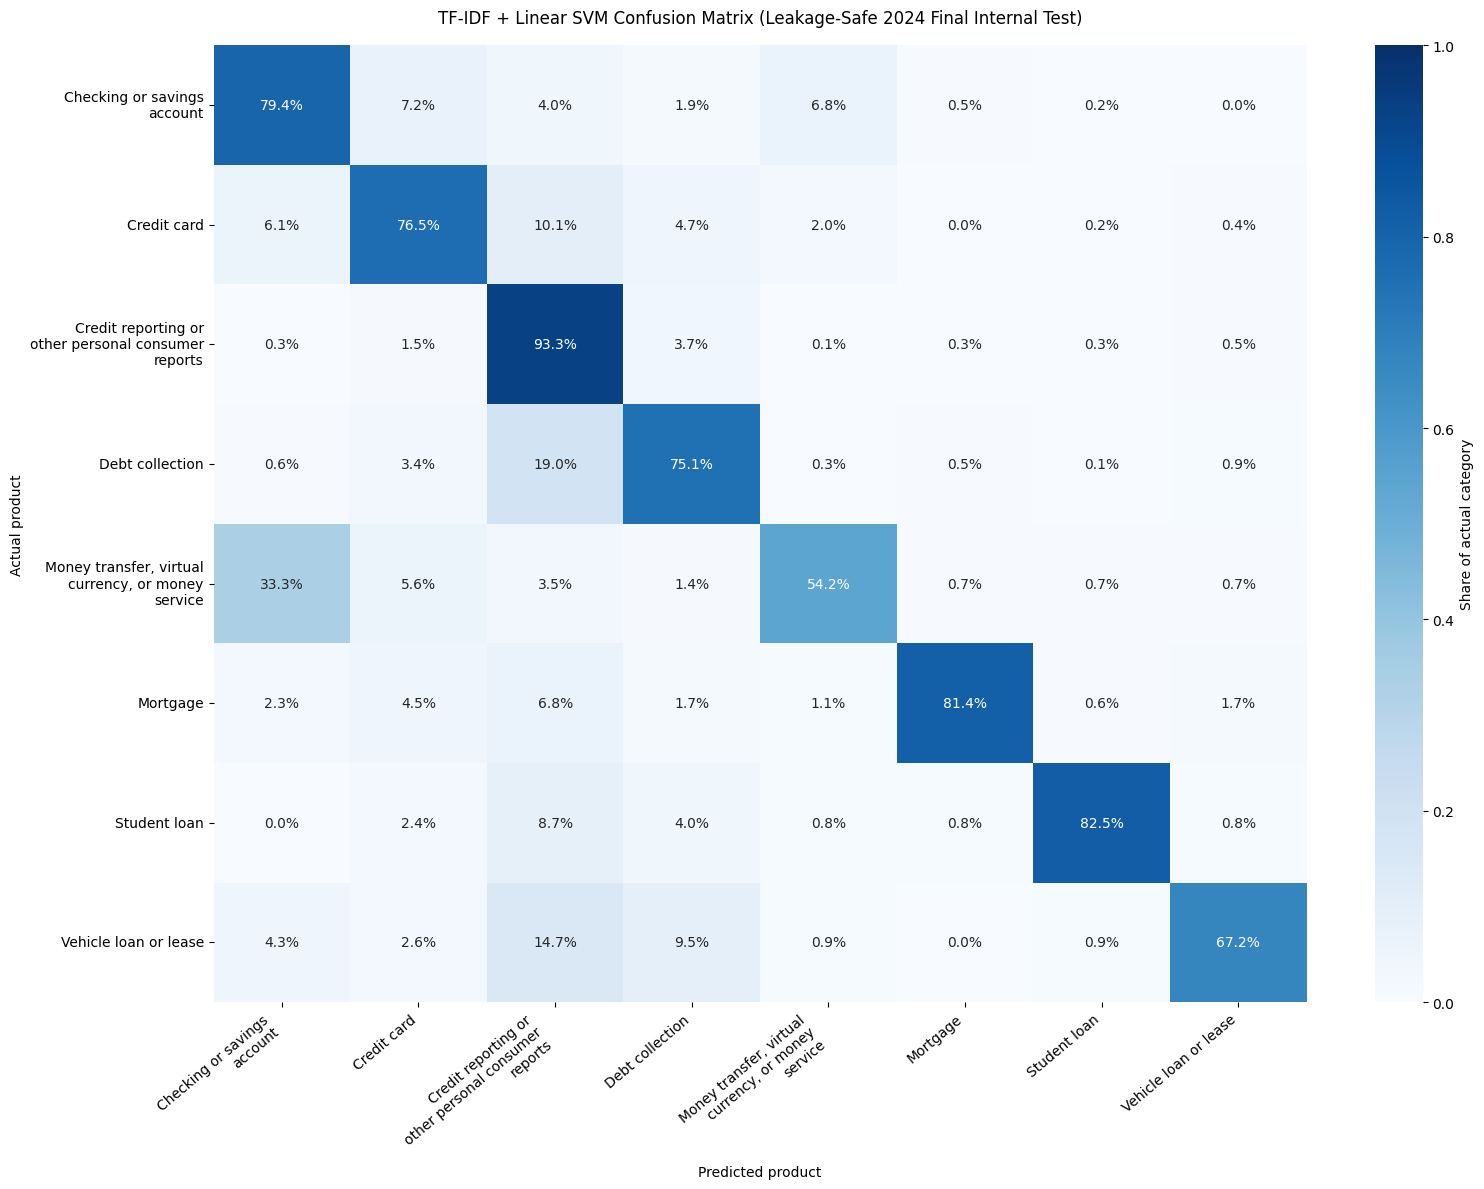

Saved corrected confusion matrix: reports\figures\confusion_matrix.png


In [11]:
wrapped_labels = [textwrap.fill(label, width=24) for label in pipeline_class_order]

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    confusion_normalized,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=wrapped_labels,
    yticklabels=wrapped_labels,
    cbar_kws={"label": "Share of actual category"},
    ax=ax,
)
ax.set_title(
    f"{selected_model_name} Confusion Matrix (Leakage-Safe 2024 Final Internal Test)",
    pad=16,
)
ax.set_xlabel("Predicted product")
ax.set_ylabel("Actual product")
ax.tick_params(axis="x", labelrotation=40)
for tick_label in ax.get_xticklabels():
    tick_label.set_horizontalalignment("right")
ax.tick_params(axis="y", labelrotation=0)

fig.tight_layout()
fig.savefig(CONFUSION_MATRIX_PATH, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved corrected confusion matrix: {CONFUSION_MATRIX_PATH.relative_to(PROJECT_ROOT)}")

## 8. Save and Validate the Local Model Artifact

In [12]:
# Recheck the key invariants before saving the corrected fitted pipeline.
assert len(development_test_overlap) == 0
assert remediated_df.groupby("normalized_text_hash")["product"].nunique().max() == 1
assert set(LOCKED_CATEGORIES) == set(selected_pipeline.classes_)
assert set(final_test_predictions).issubset(set(selected_pipeline.classes_))
assert list(selected_pipeline.named_steps) == ["tfidf", "classifier"]

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(selected_pipeline, MODEL_PATH, compress=3)

reloaded_pipeline = joblib.load(MODEL_PATH)
assert list(reloaded_pipeline.named_steps) == ["tfidf", "classifier"]
assert np.array_equal(reloaded_pipeline.classes_, selected_pipeline.classes_)

model_size_bytes = MODEL_PATH.stat().st_size
model_size_mb = model_size_bytes / (1024 ** 2)
environment_metadata = {
    "Python": platform.python_version(),
    "Scikit-learn": sklearn.__version__,
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Model file size (bytes)": model_size_bytes,
    "Model file size (MB)": round(model_size_mb, 2),
}

print("Corrected local model artifact saved and reloaded successfully.")
for name, value in environment_metadata.items():
    print(f"{name}: {value}")
print("Pipeline class order:")
for class_index, class_name in enumerate(reloaded_pipeline.classes_):
    print(f"  {class_index}: {class_name}")
print("Git policy: local model artifact only; models/*.joblib remains ignored.")

Corrected local model artifact saved and reloaded successfully.
Python: 3.11.15
Scikit-learn: 1.9.0
Pandas: 3.0.3
NumPy: 2.4.6
Model file size (bytes): 3392109
Model file size (MB): 3.23
Pipeline class order:
  0: Checking or savings account
  1: Credit card
  2: Credit reporting or other personal consumer reports
  3: Debt collection
  4: Money transfer, virtual currency, or money service
  5: Mortgage
  6: Student loan
  7: Vehicle loan or lease
Git policy: local model artifact only; models/*.joblib remains ignored.


## 9. Scope Note

This remediation uses only the local processed 2024 dataset. It removes normalized duplicate-text leakage, selects the Version 1 baseline with development-only group-aware cross-validation, and evaluates the selected pipeline once on a leakage-safe final internal test fold.

The results remain internal development evidence. They do not establish production readiness, deployment readiness, confidence-based routing performance, or 2025 out-of-time performance. Week 8 routing work remains pending.